# Day 3 · Notebook 3 — Semi-supervised learning
### ML Bootcamp · Day 3 of 5

**Situation:** you have 1,437 images of handwritten digits, but only **50** have been labelled — labelling is slow and expensive. Can the 1,387 **unlabelled** images still help?

In this notebook you will:
1. Hide 96.5% of the labels *(Part 1)*
2. Train on the 50 labels only — our baseline *(Part 2)*
3. Try **self-training** *(Part 3)* and **label spreading** *(Part 4)*
4. Find out how many labels you really need *(Part 5)*

> No internet needed. Runs in about a minute. 🧠 = think about it, ✍️ = exercise.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.semi_supervised import SelfTrainingClassifier, LabelSpreading

digits = load_digits()
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=42, stratify=digits.target)
print("Training images:", len(X_train), "| Test images:", len(X_test))

Training images: 1437 | Test images: 360


---
## Part 1 · Hide most of the labels
scikit-learn marks an **unlabelled** example with the label **−1**. We keep 50 labels chosen at random.

In [2]:
N_LABELS = 50
rng = np.random.RandomState(0)
labelled_idx = rng.choice(len(y_train), N_LABELS, replace=False)

y_partial = np.full(len(y_train), -1)          # everything unlabelled...
y_partial[labelled_idx] = y_train[labelled_idx]  # ...except 50 images

print(f"Labelled: {(y_partial != -1).sum()}  |  Unlabelled: {(y_partial == -1).sum()}")
print("Labels per digit:", np.bincount(y_train[labelled_idx]))

Labelled: 50  |  Unlabelled: 1387
Labels per digit: [6 5 5 4 6 5 3 6 6 4]


---
## Part 2 · Baseline: use only the 50 labelled images

In [3]:
def make_model():
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))

baseline = make_model().fit(X_train[labelled_idx], y_train[labelled_idx])
acc_baseline = baseline.score(X_test, y_test)
print(f"Only 50 labels: {acc_baseline:.1%}")

Only 50 labels: 86.1%


---
## Part 3 · Self-training
1. Train on the labelled images
2. Predict the unlabelled ones
3. Keep only the **confident** guesses (probability ≥ 0.9) as new labels
4. Retrain, repeat

In [4]:
self_train = SelfTrainingClassifier(make_model(), threshold=0.9)
self_train.fit(X_train, y_partial)

added = (self_train.labeled_iter_ > 0).sum()
acc_self = self_train.score(X_test, y_test)
print(f"Self-training added {added} images as new labels")
print(f"Accuracy: {acc_self:.1%}")

Self-training added 1172 images as new labels
Accuracy: 90.0%


---
## Part 4 · Label spreading
Connect each image to its 7 most similar images. Labels **spread** through these connections, like news through a group of friends.

In [5]:
spread = LabelSpreading(kernel="knn", n_neighbors=7)
spread.fit(X_train, y_partial)
acc_spread = spread.score(X_test, y_test)

hidden = y_partial == -1
guess_acc = (spread.transduction_[hidden] == y_train[hidden]).mean()
print(f"Label spreading accuracy on test images: {acc_spread:.1%}")
print(f"Its guesses for the 1,387 hidden labels were right {guess_acc:.1%} of the time")

Label spreading accuracy on test images: 95.3%
Its guesses for the 1,387 hidden labels were right 91.1% of the time


Let's look at some of the labels it guessed:

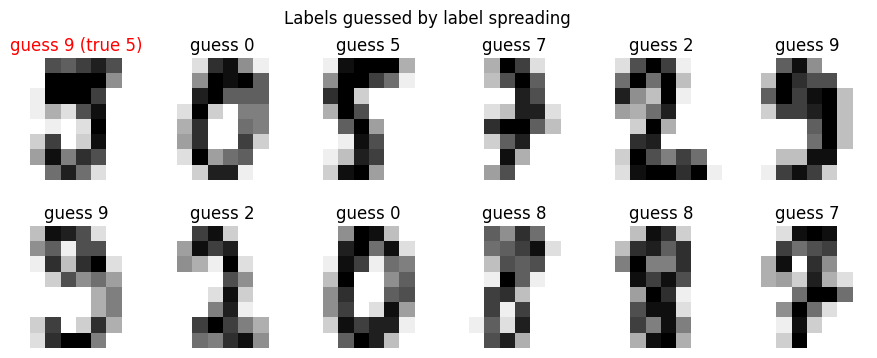

In [6]:
examples = np.where(hidden)[0][:12]
fig, axes = plt.subplots(2, 6, figsize=(11, 4))
for ax, i in zip(axes.ravel(), examples):
    ax.imshow(X_train[i].reshape(8, 8), cmap="gray_r")
    guess, truth = spread.transduction_[i], y_train[i]
    ax.set_title(f"guess {guess}" + ("" if guess == truth else f" (true {truth})"),
                 color="black" if guess == truth else "red")
    ax.axis("off")
plt.suptitle("Labels guessed by label spreading")
plt.show()

### Compare everything

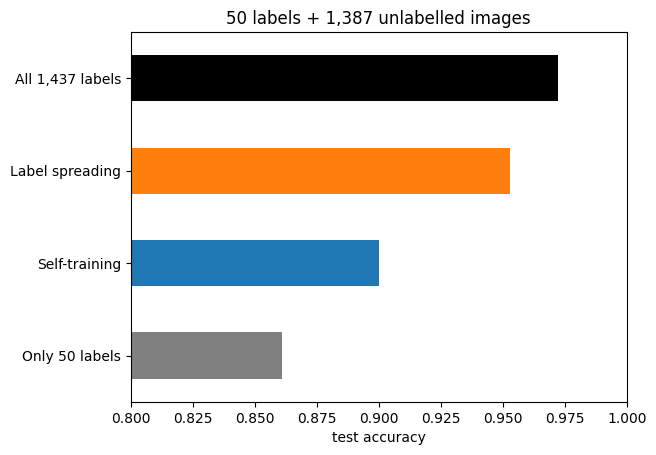

,0
Only 50 labels,0.861
Self-training,0.900
Label spreading,0.953
"All 1,437 labels",0.972


In [7]:
full = make_model().fit(X_train, y_train)
acc_full = full.score(X_test, y_test)

summary = pd.Series({
    "Only 50 labels": acc_baseline,
    "Self-training": acc_self,
    "Label spreading": acc_spread,
    "All 1,437 labels": acc_full,
})
summary.plot(kind="barh", color=["grey", "tab:blue", "tab:orange", "black"], xlim=(0.8, 1.0))
plt.xlabel("test accuracy")
plt.title("50 labels + 1,387 unlabelled images")
plt.show()
summary.round(3)

🧠 The 1,387 unlabelled images were **free**, and they added about 9 points of accuracy.

---
## Part 5 · How many labels do you really need?

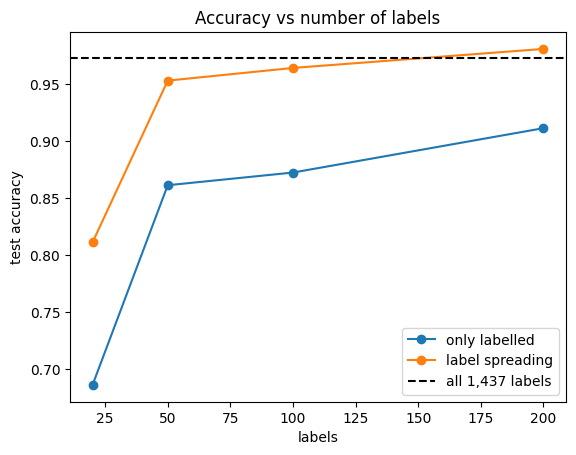

,only labelled,label spreading
labels,,
20,0.686,0.811
50,0.861,0.953
100,0.872,0.964
200,0.911,0.981


In [8]:
rows = []
for n in [20, 50, 100, 200]:
    idx = np.random.RandomState(0).choice(len(y_train), n, replace=False)
    yp = np.full(len(y_train), -1); yp[idx] = y_train[idx]
    only = make_model().fit(X_train[idx], y_train[idx]).score(X_test, y_test)
    ls = LabelSpreading(kernel="knn", n_neighbors=7).fit(X_train, yp).score(X_test, y_test)
    rows.append({"labels": n, "only labelled": only, "label spreading": ls})

curve = pd.DataFrame(rows).set_index("labels")
curve.plot(marker="o")
plt.axhline(acc_full, color="black", linestyle="--", label="all 1,437 labels")
plt.ylabel("test accuracy"); plt.legend()
plt.title("Accuracy vs number of labels")
plt.show()
curve.round(3)

> ✍️ **Exercises**
> 1. Try `n_neighbors` = 3, 7, 15 in `LabelSpreading` with 50 labels. Which works best?
> 2. Change the self-training `threshold` to 0.7 and 0.99. How many images get added, and what happens to accuracy?
> 3. 🧠 Why might label spreading work *worse* on messy real-world data than on these clean digits?

---
## 🎯 Recap
Unlabelled data is cheap. **Self-training** lets a model label its own confident guesses; **label spreading** passes labels to similar neighbours. With 3.5% of the labels we got close to the full-label accuracy.

---
## ✅ Solutions

In [ ]:
# Exercise 1
for k in [3, 7, 15]:
    print(f"n_neighbors={k:2d}: {LabelSpreading(kernel='knn', n_neighbors=k).fit(X_train, y_partial).score(X_test, y_test):.1%}")

In [ ]:
# Exercise 2
for th in [0.7, 0.9, 0.99]:
    st = SelfTrainingClassifier(make_model(), threshold=th).fit(X_train, y_partial)
    print(f"threshold {th}: added {(st.labeled_iter_ > 0).sum():4d} images, accuracy {st.score(X_test, y_test):.1%}")

**Exercise 3:** label spreading assumes that *similar-looking examples share the same label*. In messy data (blurry photos, noisy sensors, overlapping classes) neighbours often belong to different classes, so wrong labels spread too. Always check a sample of the guessed labels by hand before trusting them.